In [1]:
import numpy as np
import pandas as pd

In [5]:
books = pd.read_csv("C:\\Users\\abhis\\Downloads\\Books.csv")
users = pd.read_csv("C:\\Users\\abhis\\Downloads\\Users.csv")
ratings = pd.read_csv("C:\\Users\\abhis\\Downloads\\Ratings.csv")

C:\Users\abhis\AppData\Local\Temp\ipykernel_3172\553651630.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("C:\\Users\\abhis\\Downloads\\Books.csv")


In [6]:
print(books)

              ISBN                                         Book-Title  \
0       0195153448                                Classical Mythology   
1       0002005018                                       Clara Callan   
2       0060973129                               Decision in Normandy   
3       0374157065  Flu: The Story of the Great Influenza Pandemic...   
4       0393045218                             The Mummies of Urumchi   
...            ...                                                ...   
271355  0440400988                         There's a Bat in Bunk Five   
271356  0525447644                            From One to One Hundred   
271357  006008667X  Lily Dale : The True Story of the Town that Ta...   
271358  0192126040                        Republic (World's Classics)   
271359  0767409752  A Guided Tour of Rene Descartes' Meditations o...   

                 Book-Author Year-Of-Publication  \
0         Mark P. O. Morford                2002   
1       Richard Bru

In [7]:
print(users)

        User-ID                            Location   Age
0             1                  nyc, new york, usa   NaN
1             2           stockton, california, usa  18.0
2             3     moscow, yukon territory, russia   NaN
3             4           porto, v.n.gaia, portugal  17.0
4             5  farnborough, hants, united kingdom   NaN
...         ...                                 ...   ...
278853   278854               portland, oregon, usa   NaN
278854   278855  tacoma, washington, united kingdom  50.0
278855   278856           brampton, ontario, canada   NaN
278856   278857           knoxville, tennessee, usa   NaN
278857   278858                dublin, n/a, ireland   NaN

[278858 rows x 3 columns]


In [9]:
print(ratings)

         User-ID         ISBN  Book-Rating
0         276725   034545104X            0
1         276726   0155061224            5
2         276727   0446520802            0
3         276729   052165615X            3
4         276729   0521795028            6
...          ...          ...          ...
1149775   276704   1563526298            9
1149776   276706   0679447156            0
1149777   276709   0515107662           10
1149778   276721   0590442449           10
1149779   276723  05162443314            8

[1149780 rows x 3 columns]


In [10]:
books['Image-URL-M'][1]

'http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg'

In [11]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [12]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [13]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [14]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [15]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [16]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [17]:
books.duplicated().sum()

0

In [18]:
ratings.duplicated().sum()

0

In [19]:
users.duplicated().sum()

0

## Exploratory Data Analysis (EDA)

We analyse each of the three datasets **separately** before combining them.
The goal is to understand the shape, quality, and distribution of every column
before building any recommendation model.

---

### EDA — Books Dataset

The `books` dataframe has **271,360 rows** and **8 columns**:
`ISBN`, `Book-Title`, `Book-Author`, `Year-Of-Publication`, `Publisher`, `Image-URL-S`, `Image-URL-M`, `Image-URL-L`

In [20]:
# ── Books EDA : Step 1 — Basic Info & Data Types ─────────────────────────
# .info() gives us:
#   - number of rows and columns
#   - data type of each column  (object = string, int64 = integer, etc.)
#   - number of non-null entries per column  (null count = total - non-null)
#   - memory usage of the dataframe

print('BOOKS — Basic Info')
print('='*50)
books.info()


BOOKS — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [21]:
# ── Books EDA : Step 2 — First Look at the Data ───────────────────────────
# .head() shows the first 5 rows — useful for spotting format issues early

books.head()


,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [22]:
# ── Books EDA : Step 3 — Statistical Summary of Numeric Columns ───────────
# .describe() gives count, mean, std, min, quartiles, and max
# For books the only truly numeric column is Year-Of-Publication

books.describe(include='all').T   # .T transposes so columns become rows (easier to read)


,count,unique,top,freq
ISBN,271360,271360,0195153448,1
Book-Title,271360,242135,Selected Poems,27
Book-Author,271358,102022,Agatha Christie,632
Year-Of-Publication,271360,202,2002,13903
Publisher,271358,16807,Harlequin,7535
Image-URL-S,271360,271044,http://images.amazon.com/images/P/185326119X.0...,2
Image-URL-M,271360,271044,http://images.amazon.com/images/P/185326119X.0...,2
Image-URL-L,271357,271041,http://images.amazon.com/images/P/225307649X.0...,2


In [23]:
# ── Books EDA : Step 4 — Missing Value Analysis ───────────────────────────
# We compute both the raw count AND the percentage for each column
# so we know how serious each gap is

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

missing = pd.DataFrame({
    'Missing Count'   : books.isnull().sum(),
    'Missing %'       : (books.isnull().sum() / len(books) * 100).round(2)
})
print('Missing values in Books dataset:')
print(missing[missing['Missing Count'] > 0])


Missing values in Books dataset:
             Missing Count  Missing %
Book-Author              2        0.0
Publisher                2        0.0
Image-URL-L              3        0.0


In [24]:
# ── Books EDA : Step 5 — Cardinality (Unique Value Counts) ────────────────
# Cardinality tells us how many distinct values exist in each column.
# High cardinality in ISBN / Book-Title is expected.
# Very high cardinality in Publisher or Author would indicate data issues.

unique_counts = books.nunique().reset_index()
unique_counts.columns = ['Column', 'Unique Values']
print('Cardinality of each column in Books:')
print(unique_counts.to_string(index=False))


Cardinality of each column in Books:
             Column  Unique Values
               ISBN         271360
         Book-Title         242135
        Book-Author         102022
Year-Of-Publication            202
          Publisher          16807
        Image-URL-S         271044
        Image-URL-M         271044
        Image-URL-L         271041


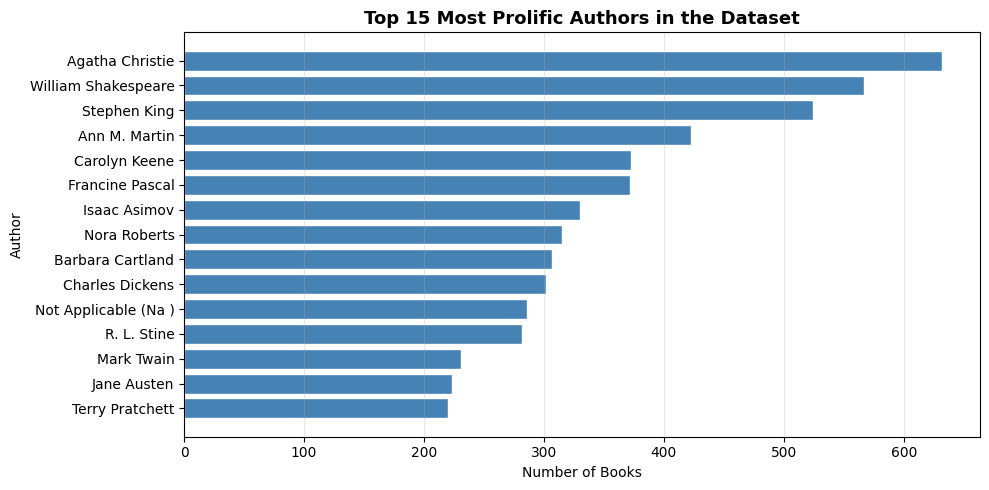

              Author  Book Count
     Agatha Christie         632
 William Shakespeare         567
        Stephen King         524
       Ann M. Martin         423
       Carolyn Keene         373
     Francine Pascal         372
        Isaac Asimov         330
        Nora Roberts         315
    Barbara Cartland         307
     Charles Dickens         302
Not Applicable (Na )         286
         R. L. Stine         282
          Mark Twain         231
         Jane Austen         223
     Terry Pratchett         220


In [25]:
# ── Books EDA : Step 6 — Top 15 Most Prolific Authors ─────────────────────
# We count how many distinct books (by ISBN) each author contributed.
# This gives a sense of which authors dominate the catalogue.

top_authors = (
    books['Book-Author']
    .value_counts()         # count occurrences of each author
    .head(15)               # keep top 15
    .reset_index()
)
top_authors.columns = ['Author', 'Book Count']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_authors['Author'][::-1], top_authors['Book Count'][::-1],
        color='steelblue', edgecolor='white')
ax.set_title('Top 15 Most Prolific Authors in the Dataset', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Books')
ax.set_ylabel('Author')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(top_authors.to_string(index=False))


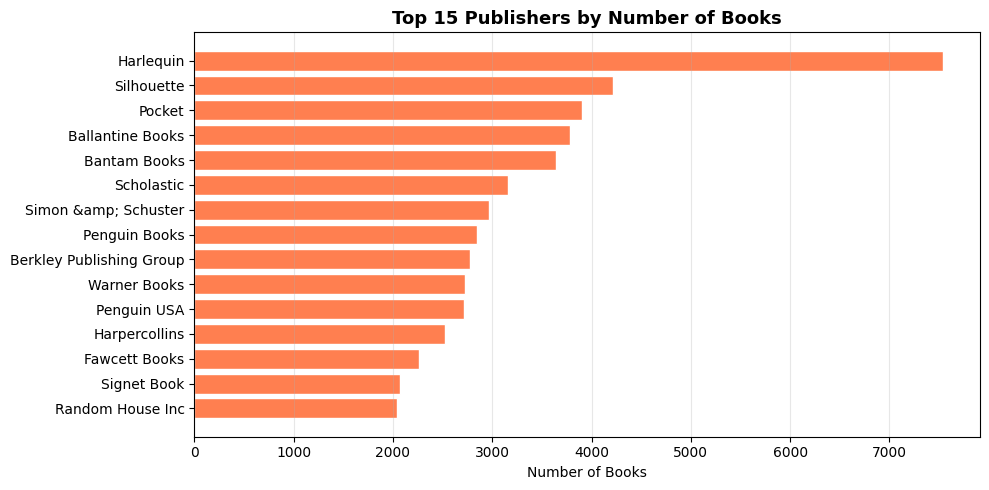

               Publisher  Book Count
               Harlequin        7535
              Silhouette        4220
                  Pocket        3905
        Ballantine Books        3783
            Bantam Books        3646
              Scholastic        3160
    Simon &amp; Schuster        2971
           Penguin Books        2844
Berkley Publishing Group        2771
            Warner Books        2727
             Penguin USA        2717
           Harpercollins        2525
           Fawcett Books        2258
             Signet Book        2070
        Random House Inc        2045


In [26]:
# ── Books EDA : Step 7 — Top 15 Publishers ────────────────────────────────
# Publisher concentration reveals if a few big houses dominate.
# This matters for content-based filtering — publisher can be a feature.

top_publishers = (
    books['Publisher']
    .value_counts()
    .head(15)
    .reset_index()
)
top_publishers.columns = ['Publisher', 'Book Count']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_publishers['Publisher'][::-1], top_publishers['Book Count'][::-1],
        color='coral', edgecolor='white')
ax.set_title('Top 15 Publishers by Number of Books', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Books')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()
print(top_publishers.to_string(index=False))


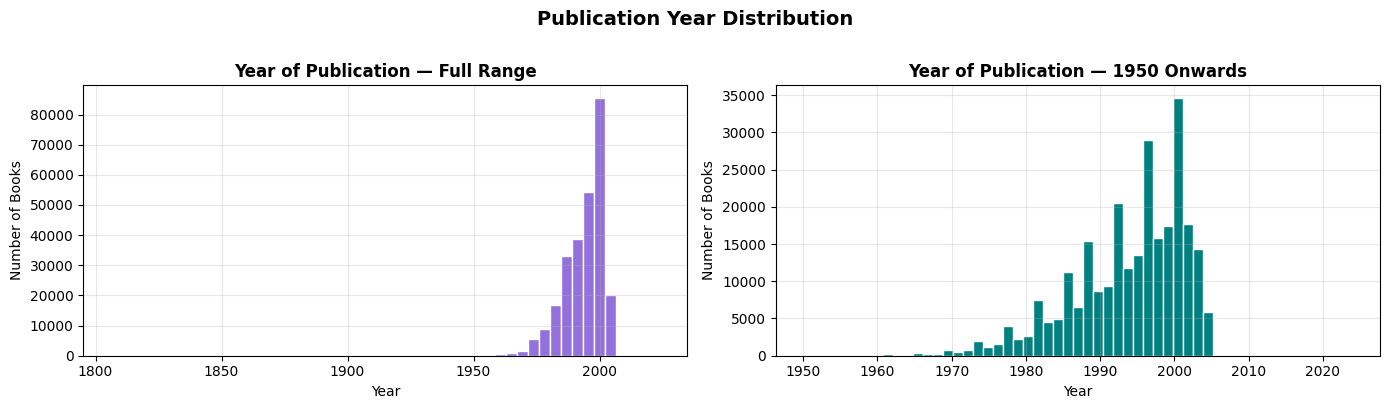

Min year (cleaned): 1806
Max year (cleaned): 2024
Median year       : 1996
Rows with invalid year: 4635


In [27]:
# ── Books EDA : Step 8 — Year of Publication Distribution ─────────────────
# We first coerce to numeric (the column has some stray string values),
# then clip to a sensible range before plotting.
# The histogram shows which decades produced the most books in this dataset.

year_series = pd.to_numeric(books['Year-Of-Publication'], errors='coerce')
year_clean  = year_series[(year_series >= 1800) & (year_series <= 2024)].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full range histogram
axes[0].hist(year_clean, bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Year of Publication — Full Range', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Books')
axes[0].grid(alpha=0.3)

# Right: zoomed into the most populated range (1950 onwards)
recent = year_clean[year_clean >= 1950]
axes[1].hist(recent, bins=55, color='teal', edgecolor='white')
axes[1].set_title('Year of Publication — 1950 Onwards', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Books')
axes[1].grid(alpha=0.3)

plt.suptitle('Publication Year Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Min year (cleaned): {year_clean.min():.0f}')
print(f'Max year (cleaned): {year_clean.max():.0f}')
print(f'Median year       : {year_clean.median():.0f}')
print(f'Rows with invalid year: {year_series.isna().sum() + ((year_series<1800)|(year_series>2024)).sum()}')


In [28]:
# ── Books EDA : Step 9 — Duplicate Book Titles ────────────────────────────
# The same title can appear multiple times with different ISBNs
# (different editions, publishers, or data entry issues).
# We identify titles with the highest duplication count.

title_counts = books['Book-Title'].value_counts()
duplicated_titles = title_counts[title_counts > 1]

print(f'Total unique titles       : {books["Book-Title"].nunique():,}')
print(f'Total rows (incl. dupes)  : {len(books):,}')
print(f'Titles appearing > 1 time : {len(duplicated_titles):,}')
print()
print('Top 10 most duplicated titles:')
print(duplicated_titles.head(10).to_string())


Total unique titles       : 242,135
Total rows (incl. dupes)  : 271,360
Titles appearing > 1 time : 19,907

Top 10 most duplicated titles:
Book-Title
Selected Poems                    27
Little Women                      24
Wuthering Heights                 21
The Secret Garden                 20
Dracula                           20
Adventures of Huckleberry Finn    20
Jane Eyre                         19
The Night Before Christmas        18
Pride and Prejudice               18
Great Expectations                17


---
### EDA — Users Dataset

The `users` dataframe has **278,858 rows** and **3 columns**:
`User-ID`, `Location`, `Age`

Key challenge: `Age` has **~40% missing values** and unrealistic outliers.

In [29]:
# ── Users EDA : Step 1 — Basic Info & Data Types ──────────────────────────

print('USERS — Basic Info')
print('='*50)
users.info()


USERS — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278858 entries, 0 to 278857
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   User-ID   278858 non-null  int64  
 1   Location  278858 non-null  object 
 2   Age       168096 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 6.4+ MB


In [30]:
# ── Users EDA : Step 2 — First Look at the Data ───────────────────────────

users.head(8)


,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN
5,6,"santa monica, california, usa",61.0
6,7,"washington, dc, usa",NaN
7,8,"timmins, ontario, canada",NaN


In [31]:
# ── Users EDA : Step 3 — Statistical Summary ──────────────────────────────
# Age is the only numeric column; all other columns are categorical/ID.
# Pay attention to the min and max of Age — they reveal outliers.

print('Age column — statistical summary:')
print(users['Age'].describe())


Age column — statistical summary:
count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64


Missing values in Users dataset:
          Missing Count  Missing %
User-ID               0       0.00
Location              0       0.00
Age              110762      39.72


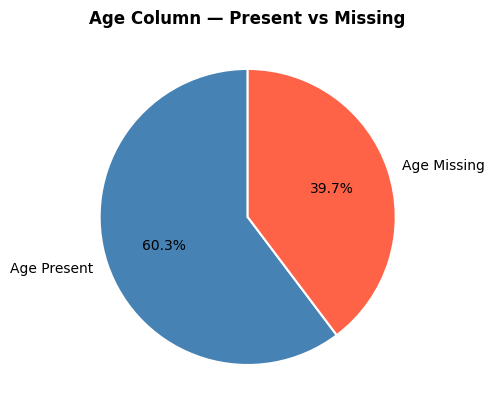

In [32]:
# ── Users EDA : Step 4 — Missing Value Analysis ───────────────────────────

missing_users = pd.DataFrame({
    'Missing Count' : users.isnull().sum(),
    'Missing %'     : (users.isnull().sum() / len(users) * 100).round(2)
})
print('Missing values in Users dataset:')
print(missing_users)

# Visualise missing vs present for the Age column
labels  = ['Age Present', 'Age Missing']
sizes   = [users['Age'].notna().sum(), users['Age'].isna().sum()]
colors  = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
ax.set_title('Age Column — Present vs Missing', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


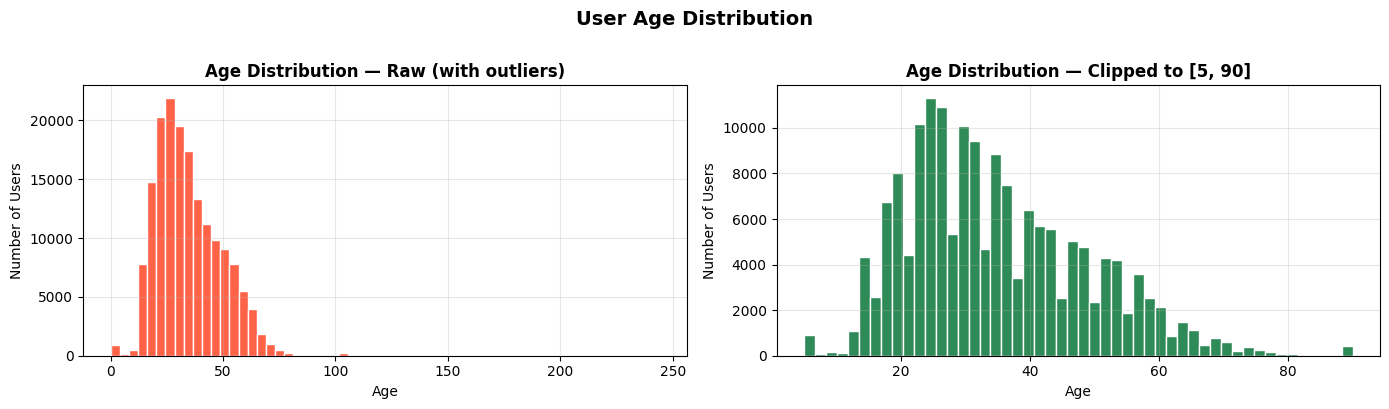

Users with age < 5  : 882
Users with age > 90 : 430
Age median (valid)  : 32.0


In [33]:
# ── Users EDA : Step 5 — Age Distribution ─────────────────────────────────
# We plot the raw age distribution BEFORE any cleaning to expose outliers.
# Left plot: full range (shows outliers like age=0 or age=244)
# Right plot: clipped to [5, 90] — the realistic range

age_raw    = users['Age'].dropna()
age_clipped = age_raw.clip(lower=5, upper=90)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: raw (unclipped)
axes[0].hist(age_raw, bins=60, color='tomato', edgecolor='white')
axes[0].set_title('Age Distribution — Raw (with outliers)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')
axes[0].grid(alpha=0.3)

# Right: clipped to sensible range
axes[1].hist(age_clipped, bins=50, color='seagreen', edgecolor='white')
axes[1].set_title('Age Distribution — Clipped to [5, 90]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Number of Users')
axes[1].grid(alpha=0.3)

plt.suptitle('User Age Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Users with age < 5  : {(age_raw < 5).sum()}')
print(f'Users with age > 90 : {(age_raw > 90).sum()}')
print(f'Age median (valid)  : {age_raw[(age_raw>=5)&(age_raw<=90)].median():.1f}')


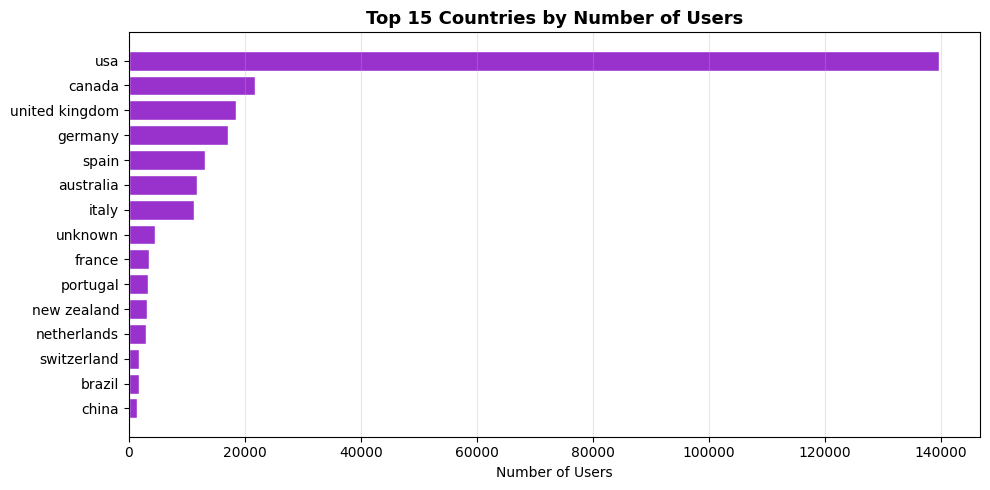

Total unique countries/regions : 708
       Country  User Count
           usa      139711
        canada       21658
united kingdom       18538
       germany       17043
         spain       13147
     australia       11784
         italy       11266
       unknown        4579
        france        3455
      portugal        3325
   new zealand        3097
   netherlands        3025
   switzerland        1745
        brazil        1674
         china        1488


In [34]:
# ── Users EDA : Step 6 — Top 15 Countries ─────────────────────────────────
# We extract the country (last segment of Location) and count users per country.
# This shows the geographic spread of the dataset.

country_series = (
    users['Location']
    .str.split(',')
    .str[-1]
    .str.strip()
    .str.lower()
    .replace('', 'unknown')
)

top_countries = country_series.value_counts().head(15).reset_index()
top_countries.columns = ['Country', 'User Count']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_countries['Country'][::-1], top_countries['User Count'][::-1],
        color='darkorchid', edgecolor='white')
ax.set_title('Top 15 Countries by Number of Users', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Users')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total unique countries/regions : {country_series.nunique()}')
print(top_countries.to_string(index=False))


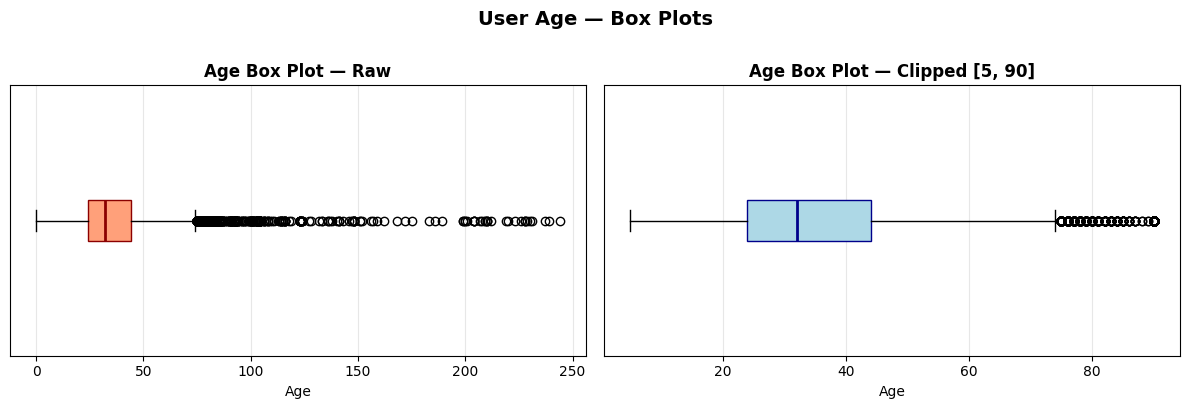

In [35]:
# ── Users EDA : Step 7 — Age Box Plot (Outlier Visualisation) ─────────────
# A box plot clearly shows the median, IQR, and outliers in the Age column.
# The whiskers extend to 1.5 × IQR; points beyond that are plotted individually.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: raw age
axes[0].boxplot(users['Age'].dropna(), vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightsalmon', color='darkred'),
               medianprops=dict(color='darkred', linewidth=2))
axes[0].set_title('Age Box Plot — Raw', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_yticks([])
axes[0].grid(axis='x', alpha=0.3)

# Right: clipped
axes[1].boxplot(users['Age'].dropna().clip(5,90), vert=False, patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='darkblue'),
               medianprops=dict(color='darkblue', linewidth=2))
axes[1].set_title('Age Box Plot — Clipped [5, 90]', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Age')
axes[1].set_yticks([])
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('User Age — Box Plots', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


In [36]:
# ── Users EDA : Step 8 — User ID Range & Uniqueness ──────────────────────
# User-ID should be a unique identifier with no gaps.
# We verify uniqueness and check the ID range.

print(f'Total users            : {len(users):,}')
print(f'Unique User-IDs        : {users["User-ID"].nunique():,}')
print(f'Duplicate User-ID rows : {users.duplicated("User-ID").sum()}')
print(f'Min User-ID            : {users["User-ID"].min()}')
print(f'Max User-ID            : {users["User-ID"].max()}')


Total users            : 278,858
Unique User-IDs        : 278,858
Duplicate User-ID rows : 0
Min User-ID            : 1
Max User-ID            : 278858


---
### EDA — Ratings Dataset

The `ratings` dataframe has **1,149,780 rows** and **3 columns**:
`User-ID`, `ISBN`, `Book-Rating`

Key insight: `Book-Rating = 0` means **implicit interaction** (not a bad score).
Ratings 1–10 are explicit user opinions.

In [37]:
# ── Ratings EDA : Step 1 — Basic Info & Data Types ────────────────────────

print('RATINGS — Basic Info')
print('='*50)
ratings.info()


RATINGS — Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149780 entries, 0 to 1149779
Data columns (total 3 columns):
 #   Column       Non-Null Count    Dtype 
---  ------       --------------    ----- 
 0   User-ID      1149780 non-null  int64 
 1   ISBN         1149780 non-null  object
 2   Book-Rating  1149780 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 26.3+ MB


In [38]:
# ── Ratings EDA : Step 2 — First Look at the Data ─────────────────────────

ratings.head(8)


,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
5,276733,2080674722,0
6,276736,3257224281,8
7,276737,0600570967,6


In [39]:
# ── Ratings EDA : Step 3 — Statistical Summary ────────────────────────────
# Book-Rating is the only numeric column.
# Key things to check: min (should be 0), max (should be 10), mean.

print('Book-Rating — statistical summary:')
print(ratings['Book-Rating'].describe())
print()
print('Full value counts (0–10):')
print(ratings['Book-Rating'].value_counts().sort_index())


Book-Rating — statistical summary:
count    1.149780e+06
mean     2.866950e+00
std      3.854184e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      7.000000e+00
max      1.000000e+01
Name: Book-Rating, dtype: float64

Full value counts (0–10):
Book-Rating
0     716109
1       1770
2       2759
3       5996
4       8904
5      50974
6      36924
7      76457
8     103736
9      67541
10     78610
Name: count, dtype: int64


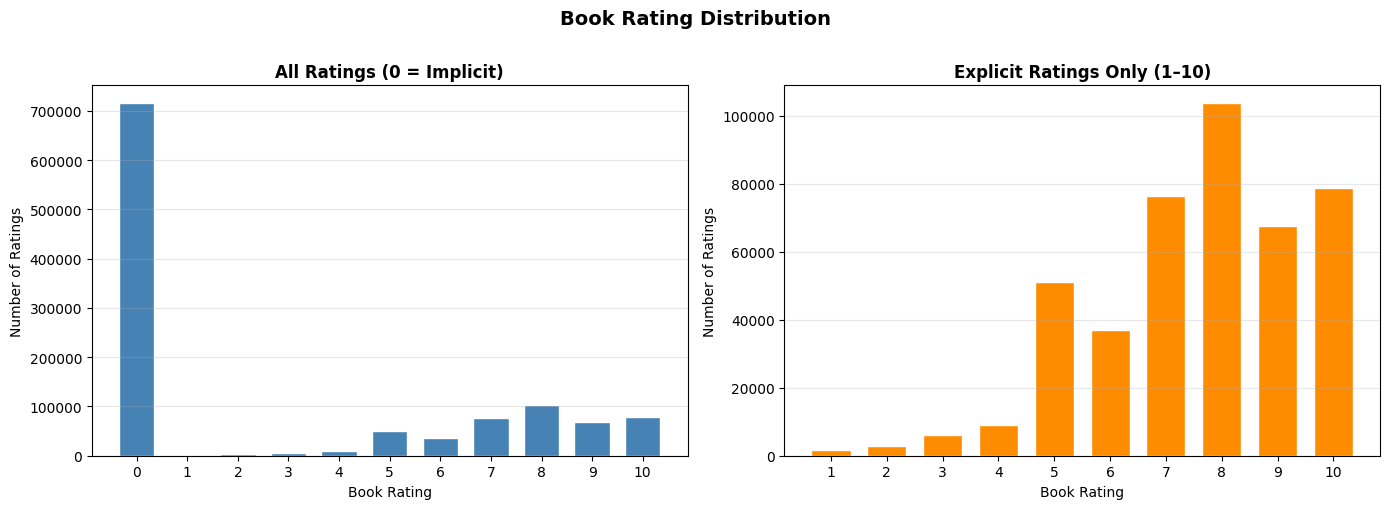

Implicit ratings (=0) : 716,109  (62.3%)
Explicit ratings (1-10): 433,671  (37.7%)


In [40]:
# ── Ratings EDA : Step 4 — Rating Distribution ────────────────────────────
# We plot two separate views:
#   Left  — all ratings including 0 (implicit)
#   Right — explicit ratings only (1–10) to see the opinion distribution

all_rating_counts      = ratings['Book-Rating'].value_counts().sort_index()
explicit_rating_counts = ratings[ratings['Book-Rating'] > 0]['Book-Rating'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: all ratings
axes[0].bar(all_rating_counts.index, all_rating_counts.values,
            color='steelblue', edgecolor='white', width=0.7)
axes[0].set_title('All Ratings (0 = Implicit)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Book Rating')
axes[0].set_ylabel('Number of Ratings')
axes[0].set_xticks(range(0, 11))
axes[0].grid(axis='y', alpha=0.3)

# Right: explicit only
axes[1].bar(explicit_rating_counts.index, explicit_rating_counts.values,
            color='darkorange', edgecolor='white', width=0.7)
axes[1].set_title('Explicit Ratings Only (1–10)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Book Rating')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_xticks(range(1, 11))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Book Rating Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

implicit_count = (ratings['Book-Rating'] == 0).sum()
explicit_count = (ratings['Book-Rating'] > 0).sum()
print(f'Implicit ratings (=0) : {implicit_count:,}  ({implicit_count/len(ratings)*100:.1f}%)')
print(f'Explicit ratings (1-10): {explicit_count:,}  ({explicit_count/len(ratings)*100:.1f}%)')


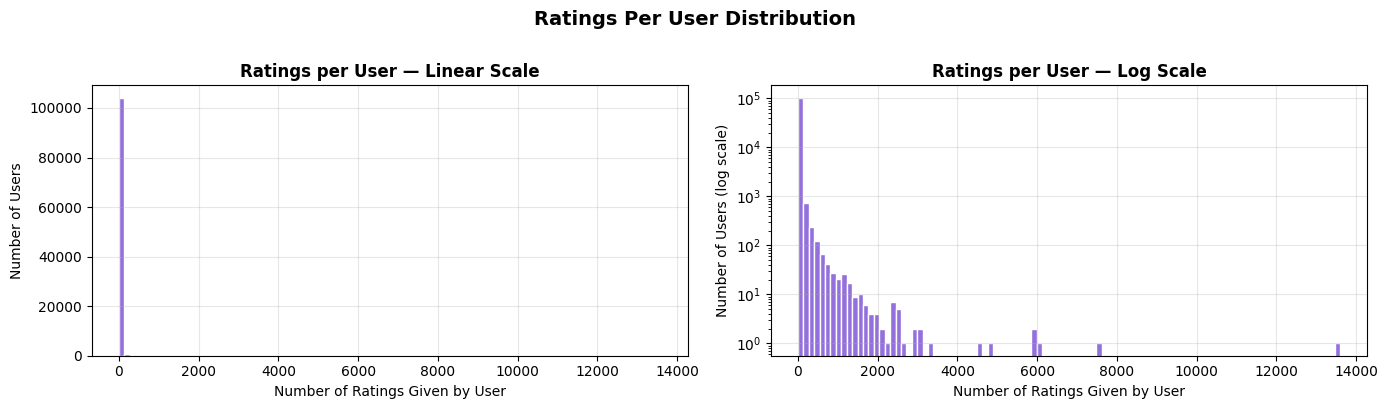

Total users who gave ratings        : 105,283
Median ratings per user             : 1.0
Mean ratings per user               : 10.9
Users with only 1 rating            : 59,166
Users with 200+ ratings             : 905


In [41]:
# ── Ratings EDA : Step 5 — Ratings Per User Distribution ──────────────────
# How many books has each user rated?
# Most users rate very few books (long-tail distribution).
# We plot on a log scale to make the long tail visible.

ratings_per_user = ratings.groupby('User-ID')['Book-Rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: linear scale
axes[0].hist(ratings_per_user, bins=100, color='mediumpurple', edgecolor='white')
axes[0].set_title('Ratings per User — Linear Scale', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Ratings Given by User')
axes[0].set_ylabel('Number of Users')
axes[0].grid(alpha=0.3)

# Right: log scale (reveals the long tail clearly)
axes[1].hist(ratings_per_user, bins=100, color='mediumpurple', edgecolor='white', log=True)
axes[1].set_title('Ratings per User — Log Scale', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Ratings Given by User')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].grid(alpha=0.3)

plt.suptitle('Ratings Per User Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Total users who gave ratings        : {len(ratings_per_user):,}')
print(f'Median ratings per user             : {ratings_per_user.median():.1f}')
print(f'Mean ratings per user               : {ratings_per_user.mean():.1f}')
print(f'Users with only 1 rating            : {(ratings_per_user==1).sum():,}')
print(f'Users with 200+ ratings             : {(ratings_per_user>=200).sum():,}')


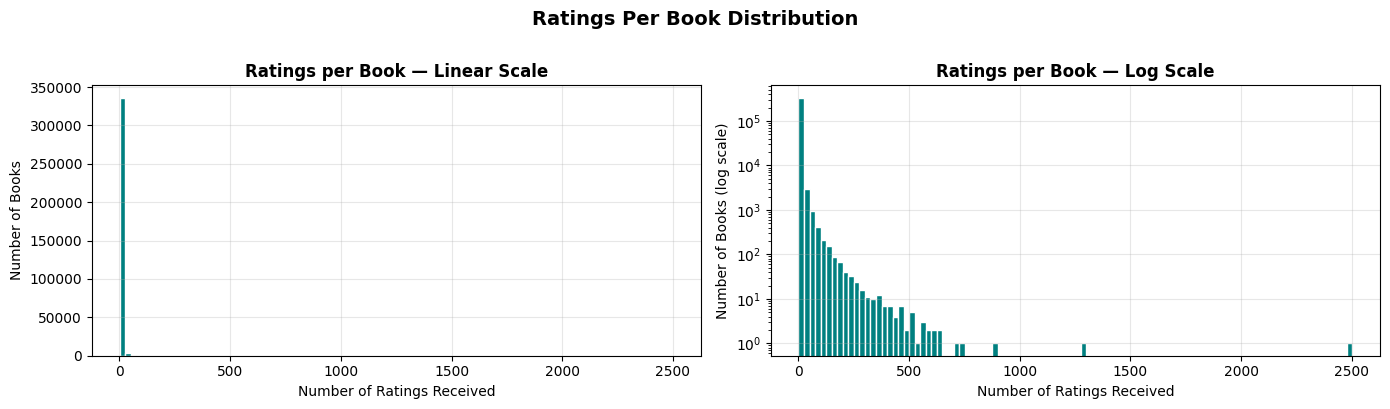

Total unique books with ratings     : 340,556
Median ratings per book             : 1.0
Mean ratings per book               : 3.38
Books with only 1 rating            : 197,045
Books with 50+ ratings              : 2,185
Books with 250+ ratings             : 124


In [42]:
# ── Ratings EDA : Step 6 — Ratings Per Book Distribution ──────────────────
# How many ratings has each book received?
# Again a classic long-tail: a few books are rated by thousands,
# most books by just 1–2 users.

ratings_per_book = ratings.groupby('ISBN')['Book-Rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(ratings_per_book, bins=100, color='teal', edgecolor='white')
axes[0].set_title('Ratings per Book — Linear Scale', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of Ratings Received')
axes[0].set_ylabel('Number of Books')
axes[0].grid(alpha=0.3)

axes[1].hist(ratings_per_book, bins=100, color='teal', edgecolor='white', log=True)
axes[1].set_title('Ratings per Book — Log Scale', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Ratings Received')
axes[1].set_ylabel('Number of Books (log scale)')
axes[1].grid(alpha=0.3)

plt.suptitle('Ratings Per Book Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Total unique books with ratings     : {len(ratings_per_book):,}')
print(f'Median ratings per book             : {ratings_per_book.median():.1f}')
print(f'Mean ratings per book               : {ratings_per_book.mean():.2f}')
print(f'Books with only 1 rating            : {(ratings_per_book==1).sum():,}')
print(f'Books with 50+ ratings              : {(ratings_per_book>=50).sum():,}')
print(f'Books with 250+ ratings             : {(ratings_per_book>=250).sum():,}')


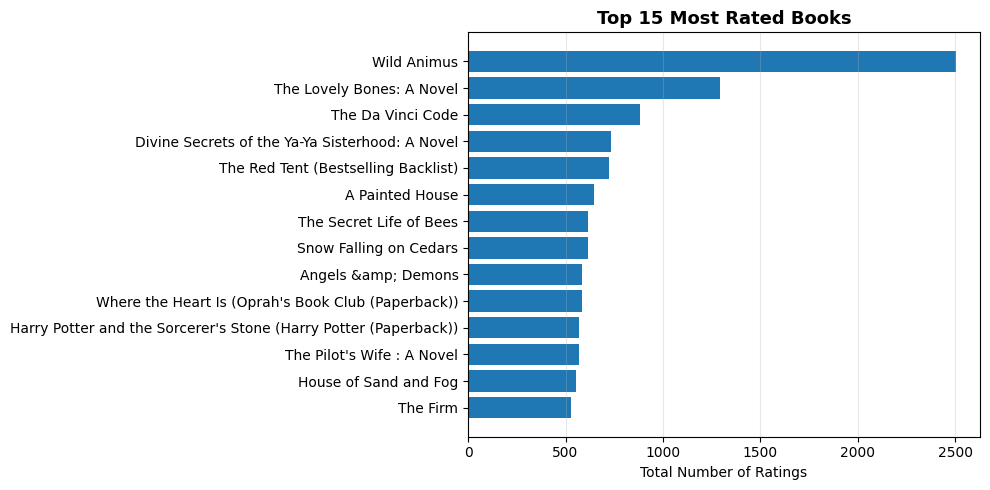

                                                      Book-Title  Total Ratings
                                                     Wild Animus           2502
                                       The Lovely Bones: A Novel           1295
                                               The Da Vinci Code            883
                 Divine Secrets of the Ya-Ya Sisterhood: A Novel            732
                             The Red Tent (Bestselling Backlist)            723
                                                 A Painted House            647
                                         The Secret Life of Bees            615
                                          Snow Falling on Cedars            614
                                             Angels &amp; Demons            586
              Where the Heart Is (Oprah's Book Club (Paperback))            585
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))            571
                                      Th

In [43]:
# ── Ratings EDA : Step 7 — Top 15 Most Rated Books ────────────────────────
# These are the books that appear most often in the ratings table.
# We join with books.csv to get the title (ratings only has ISBN).

top_rated_books = (
    ratings.groupby('ISBN')['Book-Rating']
    .count()
    .reset_index()
    .rename(columns={'Book-Rating': 'Total Ratings'})
    .sort_values('Total Ratings', ascending=False)
    .head(15)
    .merge(books[['ISBN','Book-Title']], on='ISBN', how='left')
)

# Remove missing titles
top_rated_books = top_rated_books.dropna(subset=['Book-Title'])

fig, ax = plt.subplots(figsize=(10,5))
ax.barh(
    top_rated_books['Book-Title'][::-1],
    top_rated_books['Total Ratings'][::-1]
)

ax.set_title('Top 15 Most Rated Books', fontsize=13, fontweight='bold')
ax.set_xlabel('Total Number of Ratings')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(top_rated_books[['Book-Title','Total Ratings']].to_string(index=False))

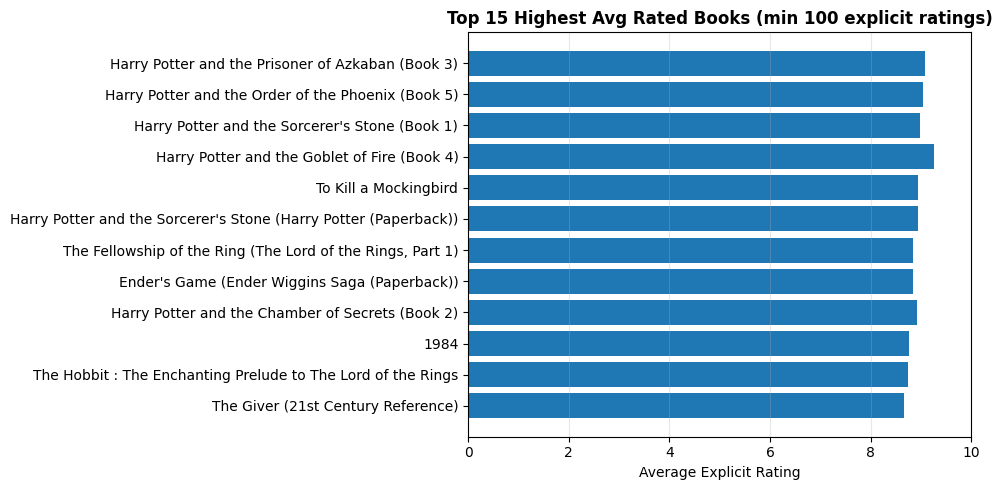

                                                      Book-Title  avg_rating  num_ratings
                    Harry Potter and the Goblet of Fire (Book 4)    9.262774          137
               Harry Potter and the Prisoner of Azkaban (Book 3)    9.082707          133
               Harry Potter and the Prisoner of Azkaban (Book 3)    9.035461          141
              Harry Potter and the Order of the Phoenix (Book 5)    9.033981          206
                  Harry Potter and the Sorcerer's Stone (Book 1)    8.983193          119
                    Harry Potter and the Goblet of Fire (Book 4)    8.954545          110
                                           To Kill a Mockingbird    8.943925          214
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))    8.939297          313
                Harry Potter and the Chamber of Secrets (Book 2)    8.920635          126
      The Fellowship of the Ring (The Lord of the Rings, Part 1)    8.839695          131
          

In [44]:
# ── Ratings EDA : Step 8 — Highest Average Rated Books (min 100 ratings) ──

#  Keep only explicit ratings (>0)
explicit = ratings[ratings['Book-Rating'] > 0]

#  Compute average rating and number of ratings per book
book_avg = (
    explicit.groupby('ISBN')['Book-Rating']
    .agg(avg_rating='mean', num_ratings='count')
    .reset_index()
)

#  Keep books with at least 100 ratings
book_avg_filtered = book_avg[book_avg['num_ratings'] >= 100]

#  Sort and keep top 15
book_avg_filtered = book_avg_filtered.sort_values(
    'avg_rating', ascending=False
).head(15)

#  Merge with books dataset to get titles
book_avg_filtered = book_avg_filtered.merge(
    books[['ISBN','Book-Title']], on='ISBN', how='left'
)

#  Remove missing titles
book_avg_filtered = book_avg_filtered.dropna(subset=['Book-Title'])

#  Plot
fig, ax = plt.subplots(figsize=(10,5))

ax.barh(
    book_avg_filtered['Book-Title'][::-1],
    book_avg_filtered['avg_rating'][::-1]
)

ax.set_title(
    'Top 15 Highest Avg Rated Books (min 100 explicit ratings)',
    fontsize=12, fontweight='bold'
)

ax.set_xlabel('Average Explicit Rating')
ax.set_xlim(0,10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

#  Print table
print(book_avg_filtered[['Book-Title','avg_rating','num_ratings']].to_string(index=False))

In [45]:
# ── Ratings EDA : Step 9 — Interaction Matrix Sparsity ────────────────────
# In collaborative filtering we build a User × Book matrix.
# Sparsity tells us what fraction of cells in that matrix are EMPTY
# (i.e. the user has not rated that book).
# High sparsity is normal — even avid readers cover <1% of all books.

total_users  = ratings['User-ID'].nunique()
total_books  = ratings['ISBN'].nunique()
total_ratings = len(ratings)

# Maximum possible interactions = every user rating every book
max_interactions = total_users * total_books

# Sparsity = fraction of the matrix that is empty
sparsity = 1 - (total_ratings / max_interactions)

print('Interaction Matrix Statistics')
print('='*45)
print(f'Total unique users   : {total_users:,}')
print(f'Total unique books   : {total_books:,}')
print(f'Total ratings        : {total_ratings:,}')
print(f'Maximum possible     : {max_interactions:,}')
print(f'Matrix sparsity      : {sparsity*100:.4f}%')
print(f'Matrix density       : {(1-sparsity)*100:.4f}%')
print()
print('Interpretation: The interaction matrix is almost completely empty.')
print('This is why collaborative filtering requires careful user/book filtering')
print('(which is done later using the 200-rating and 50-rating thresholds).')


Interaction Matrix Statistics
Total unique users   : 105,283
Total unique books   : 340,556
Total ratings        : 1,149,780
Maximum possible     : 35,854,757,348
Matrix sparsity      : 99.9968%
Matrix density       : 0.0032%

Interpretation: The interaction matrix is almost completely empty.
This is why collaborative filtering requires careful user/book filtering
(which is done later using the 200-rating and 50-rating thresholds).


## Feature Engineering

In [46]:
# Quick snapshot of all three raw dataframes before any engineering
print('books   shape:', books.shape,  ' | columns:', list(books.columns))
print('users   shape:', users.shape,  ' | columns:', list(users.columns))
print('ratings shape:', ratings.shape,' | columns:', list(ratings.columns))


books   shape: (271360, 8)  | columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L']
users   shape: (278858, 3)  | columns: ['User-ID', 'Location', 'Age']
ratings shape: (1149780, 3)  | columns: ['User-ID', 'ISBN', 'Book-Rating']


### Feature 1 — Age Group(added to users dataset)
Bin the continuous Age column into five labelled life-stage groups.

A continuous float like 34.0 is harder for a model to generalise from than a label like Adult. Binning also absorbs the noise from the many imputed missing values.

In [47]:
# Feature 1: Age Group


# Step 1 — Fill missing Age values with the median
# We use median (not mean) because age has outliers that skew the mean
median_age = users['Age'].median()
users['Age'] = users['Age'].fillna(median_age)

# Step 2 — Clip extreme ages: values outside [5, 90] are data entry errors
# e.g. age = 0 or age = 244 are clearly wrong
users['Age'] = users['Age'].clip(lower=5, upper=90)

# Step 3 — Cut the clipped age into 5 labelled life-stage bins
# pd.cut assigns each age to the correct bin based on the boundaries
age_bins   = [0, 18, 25, 35, 50, 90]                          # bin edges
age_labels = ['Teen','Young Adult','Adult','Middle-Aged','Senior']  # bin labels

users['Age-Group'] = pd.cut(
    users['Age'],
    bins   = age_bins,
    labels = age_labels,
    right  = True    # interval is (lower, upper] — upper edge is included
)

print('Age-Group distribution:')
print(users['Age-Group'].value_counts())
users[['User-ID','Age','Age-Group']].head(8)


Age-Group distribution:
Age-Group
Adult          160105
Middle-Aged     43156
Young Adult     33919
Senior          25665
Teen            16013
Name: count, dtype: int64


,User-ID,Age,Age-Group
0,1,32.0,Adult
1,2,18.0,Teen
2,3,32.0,Adult
3,4,17.0,Teen
4,5,32.0,Adult
5,6,61.0,Senior
6,7,32.0,Adult
7,8,32.0,Adult


### Feature 2 — Country
Extract the country from the free-text Location column.

- Location is stored as city, state, country. We only need the country — it is the broadest useful geographic signal and has the least spelling variation.

In [48]:

# Feature 2: Country

# Split the Location string on commas and take the LAST segment
# 'stockton, california, usa'  →  ['stockton','california','usa']  →  'usa'
users['Country'] = (
    users['Location']
    .str.split(',')      # split into a list of parts
    .str[-1]             # last part is the country
    .str.strip()         # remove leading/trailing spaces
    .str.lower()         # lowercase for consistency ('USA' == 'usa')
)

# Replace empty strings (rows with no country segment) with 'unknown'
users['Country'] = users['Country'].replace('', 'unknown')

print(f'Unique countries found: {users["Country"].nunique()}')
print('\nTop 10 countries by user count:')
print(users['Country'].value_counts().head(10))
users[['User-ID','Location','Country']].head(6)


Unique countries found: 708

Top 10 countries by user count:
Country
usa               139711
canada             21658
united kingdom     18538
germany            17043
spain              13147
australia          11784
italy              11266
unknown             4579
france              3455
portugal            3325
Name: count, dtype: int64


,User-ID,Location,Country
0,1,"nyc, new york, usa",usa
1,2,"stockton, california, usa",usa
2,3,"moscow, yukon territory, russia",russia
3,4,"porto, v.n.gaia, portugal",portugal
4,5,"farnborough, hants, united kingdom",united kingdom
5,6,"santa monica, california, usa",usa


### Feature 3 — Publication Era(from books dataset)
Group books by the decade they were published.

- Publication year as a raw number is noisy (mixed types, outliers). Grouping into decades gives a clean categorical signal — readers often prefer books from a particular era.

In [49]:
# Feature 3: Publication Era


# Step 1 — Convert to numeric; non-numeric strings (e.g. 'DK Publishing') → NaN
books['Year-Of-Publication'] = pd.to_numeric(
    books['Year-Of-Publication'], errors='coerce'
)

# Step 2 — Clamp to a realistic range; years like 0 or 2050 are errors
books['Year-Of-Publication'] = books['Year-Of-Publication'].clip(lower=1800, upper=2024)

# Step 3 — Fill remaining NaN with the median valid year
median_year = books['Year-Of-Publication'].median()
books['Year-Of-Publication'] = books['Year-Of-Publication'].fillna(median_year)

# Step 4 — Compute decade label
# Integer-divide by 10, multiply back → rounds DOWN to decade start
# Example: 1998 // 10 = 199 → 199 * 10 = 1990 → label = '1990s'
books['Publication-Era'] = (
    (books['Year-Of-Publication'] // 10 * 10)
    .astype(int)
    .astype(str) + 's'    # append 's' to form '1990s', '2000s', etc.
)

print('Publication Era distribution (sorted by decade):')
print(books['Publication-Era'].value_counts().sort_index())
books[['ISBN','Book-Title','Year-Of-Publication','Publication-Era']].head(6)


Publication Era distribution (sorted by decade):
Publication-Era
1800s      4621
1890s         1
1900s        17
1910s        23
1920s        65
1930s        57
1940s       127
1950s       623
1960s      1773
1970s     12769
1980s     52778
1990s    126019
2000s     72465
2010s         5
2020s        17
Name: count, dtype: int64


,ISBN,Book-Title,Year-Of-Publication,Publication-Era
0,0195153448,Classical Mythology,2002.0,2000s
1,0002005018,Clara Callan,2001.0,2000s
2,0060973129,Decision in Normandy,1991.0,1990s
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,1999.0,1990s
4,0393045218,The Mummies of Urumchi,1999.0,1990s
5,0399135782,The Kitchen God's Wife,1991.0,1990s


### Feature 4 — Rating Category(from ratings Column)
Convert numeric ratings (0–10) into descriptive quality labels.

- A rating of 0 is NOT a bad review — it means the user only interacted implicitly (no explicit opinion). Labelling avoids that confusion and lets us filter on quality tier easily.

In [50]:

# Feature 4: Rating Category

#
# Rating scale in this dataset:
#   0        → Implicit interaction only (no explicit score)
#   1 – 4    → Low
#   5 – 7    → Medium
#   8 – 10   → High

def categorise_rating(r):
    """Map a numeric rating to a human-readable quality label."""
    if r == 0:
        return 'Implicit'   # user read/bought but did not score
    elif r <= 4:
        return 'Low'
    elif r <= 7:
        return 'Medium'
    else:
        return 'High'

# Apply to every row in the ratings table
ratings['Rating-Category'] = ratings['Book-Rating'].apply(categorise_rating)

print('Rating Category distribution:')
print(ratings['Rating-Category'].value_counts())
ratings[['User-ID','ISBN','Book-Rating','Rating-Category']].head(10)


Rating Category distribution:
Rating-Category
Implicit    716109
High        249887
Medium      164355
Low          19429
Name: count, dtype: int64


,User-ID,ISBN,Book-Rating,Rating-Category
0,276725,034545104X,0,Implicit
1,276726,0155061224,5,Medium
2,276727,0446520802,0,Implicit
3,276729,052165615X,3,Low
4,276729,0521795028,6,Medium
5,276733,2080674722,0,Implicit
6,276736,3257224281,8,High
7,276737,0600570967,6,Medium
8,276744,038550120X,7,Medium
9,276745,342310538,10,High


### Feature 5 — User Activity Level(from users dataset)
- Classify users by how many books they have rated.

- Highly active users (rated 50+ books) give the collaborative filter much stronger signal than casual users who rated only 1–2 books. This feature lets us weight or filter users during model training.

In [51]:
# Feature 5: User Activity Level


# Count total ratings submitted by each user
user_rating_counts = (
    ratings.groupby('User-ID')['Book-Rating']
    .count()
    .reset_index()
    .rename(columns={'Book-Rating': 'Total-Ratings-Given'})
)

# Classify users into three engagement tiers
def activity_level(n):
    """Return engagement label based on number of ratings submitted."""
    if n <= 10:
        return 'Casual'     # 1  – 10  ratings
    elif n <= 50:
        return 'Moderate'   # 11 – 50  ratings
    else:
        return 'Active'     # 51+      ratings

user_rating_counts['Activity-Level'] = (
    user_rating_counts['Total-Ratings-Given'].apply(activity_level)
)

# Merge back into the users dataframe (left join keeps all users)
users = users.merge(user_rating_counts, on='User-ID', how='left')

# Users who appear in users.csv but gave zero ratings → fill gracefully
users['Total-Ratings-Given'] = users['Total-Ratings-Given'].fillna(0).astype(int)
users['Activity-Level']      = users['Activity-Level'].fillna('Casual')

print('User Activity Level distribution:')
print(users['Activity-Level'].value_counts())
users[['User-ID','Total-Ratings-Given','Activity-Level']].head(10)


User Activity Level distribution:
Activity-Level
Casual      266805
Moderate      8682
Active        3371
Name: count, dtype: int64


,User-ID,Total-Ratings-Given,Activity-Level
0,1,0,Casual
1,2,1,Casual
2,3,0,Casual
3,4,0,Casual
4,5,0,Casual
5,6,0,Casual
6,7,1,Casual
7,8,18,Moderate
8,9,3,Casual
9,10,2,Casual


### Feature 6 — Book Popularity Score(from books dataset)
- Blend rating volume and quality into one robust score.

- A book with average rating 10.0 from 2 users is NOT more popular than one with average 8.5 from 5,000 users. We use a Bayesian weighted average (same idea as IMDb's formula) that pulls low-count books towards the global mean.

In [52]:
# Feature 6: Book Popularity Score  (Bayesian Weighted Average)

# Formula:
#   score = (v / (v + m)) * R  +  (m / (v + m)) * C
#
#   v = number of ratings this book has received
#   m = minimum vote threshold (80th percentile of all vote counts)
#   R = this book's own average rating
#   C = global average rating across ALL books
#
# Effect: books with v >> m are scored mainly by R (their own quality).
#         books with v << m are pulled towards C (safe global average).

# Compute per-book vote count and average rating
book_stats = (
    ratings.groupby('ISBN')['Book-Rating']
    .agg(num_votes='count', avg_rating='mean')
    .reset_index()
)

C = book_stats['avg_rating'].mean()           # global mean rating
m = book_stats['num_votes'].quantile(0.80)    # 80th-pct vote threshold

print(f'Global mean rating (C)          : {C:.4f}')
print(f'Vote threshold m (80th pct)     : {m:.0f}')

# Apply the Bayesian formula
v = book_stats['num_votes']
R = book_stats['avg_rating']
book_stats['Popularity-Score'] = ((v / (v + m)) * R + (m / (v + m)) * C).round(4)

# Merge score back into books dataframe
books = books.merge(
    book_stats[['ISBN','num_votes','avg_rating','Popularity-Score']],
    on='ISBN', how='left'
)
books['Popularity-Score'] = books['Popularity-Score'].fillna(0)

print('\nTop 10 books by Popularity Score:')
books[['Book-Title','num_votes','avg_rating','Popularity-Score']] \
    .dropna().sort_values('Popularity-Score', ascending=False).head(10)


Global mean rating (C)          : 2.9436
Vote threshold m (80th pct)     : 3

Top 10 books by Popularity Score:


,Book-Title,num_votes,avg_rating,Popularity-Score
79431,The Blue Day Book: A Lesson in Cheering Yourse...,11.0,9.181818,7.8451
29708,Death: The High Cost of Living,9.0,9.444444,7.8192
78867,The Shrinking of Treehorn,8.0,9.500000,7.7119
159836,A Letter to Mrs. Roosevelt,8.0,9.500000,7.7119
3028,Free,54.0,7.962963,7.6988
15218,The Lord of the Rings (Leatherette Collector's...,6.0,10.000000,7.6479
15415,Sandman: The Dream Hunters,8.0,9.250000,7.5301
90512,"Le Combat ordinaire, tome 1",8.0,9.250000,7.5301
29707,Death : The Time of Your Life (Death),7.0,9.428571,7.4831
90562,"Brief Lives (Sandman, Book 7)",8.0,9.125000,7.4392


### Feature 7 — Author Book Count(from books dataset)
- Count how many books each author has in the dataset.

- Prolific authors (Stephen King, Danielle Steel) are typically well-known and their books are often recommended together. This count acts as a proxy for an author's presence and recognition in the catalogue.

In [53]:
# ─────────────────────────────────────────────────────────────────
# Feature 7: Author Book Count
# ─────────────────────────────────────────────────────────────────

# Count the number of distinct ISBNs per author
# (using ISBN avoids inflating the count due to title duplicates)
author_counts = (
    books.groupby('Book-Author')['ISBN']
    .count()
    .reset_index()
    .rename(columns={'ISBN': 'Author-Book-Count'})
)

# Merge back so every book row now also knows its author's total count
books = books.merge(author_counts, on='Book-Author', how='left')

print('Top 10 most prolific authors in the dataset:')
print(
    books[['Book-Author','Author-Book-Count']]
    .drop_duplicates()
    .sort_values('Author-Book-Count', ascending=False)
    .head(10)
    .to_string(index=False)
)
books[['Book-Title','Book-Author','Author-Book-Count']].head(6)


Top 10 most prolific authors in the dataset:
        Book-Author  Author-Book-Count
    Agatha Christie              632.0
William Shakespeare              567.0
       Stephen King              524.0
      Ann M. Martin              423.0
      Carolyn Keene              373.0
    Francine Pascal              372.0
       Isaac Asimov              330.0
       Nora Roberts              315.0
   Barbara Cartland              307.0
    Charles Dickens              302.0


,Book-Title,Book-Author,Author-Book-Count
0,Classical Mythology,Mark P. O. Morford,2.0
1,Clara Callan,Richard Bruce Wright,2.0
2,Decision in Normandy,Carlo D'Este,3.0
3,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,2.0
4,The Mummies of Urumchi,E. J. W. Barber,1.0
5,The Kitchen God's Wife,Amy Tan,49.0


### Feature 8 — Title Word Count(from books dataset)
- Count the number of words in each book title.

- Short punchy titles ('1984', 'Dune') and long descriptive ones ('The Hitchhiker's Guide to the Galaxy') attract different reading preferences. Word count is a cheap, language-agnostic proxy for title style.

In [54]:

# Feature 8: Title Word Count


books['Title-Word-Count'] = (
    books['Book-Title']
    .fillna('')       # handle the few null titles without raising an error
    .str.split()      # split on any whitespace → list of tokens
    .str.len()        # count the tokens = word count
)

print('Title Word Count — summary statistics:')
print(books['Title-Word-Count'].describe().round(2))

# Show the distribution of short vs long titles
print('\nWord count buckets:')
print(pd.cut(books['Title-Word-Count'],
             bins=[0,1,3,6,10,100],
             labels=['1 word','2-3 words','4-6 words','7-10 words','10+ words']
     ).value_counts().sort_index())
books[['Book-Title','Title-Word-Count']].head(10)


Title Word Count — summary statistics:
count    271360.00
mean          6.12
std           4.00
min           1.00
25%           3.00
50%           5.00
75%           8.00
max          45.00
Name: Title-Word-Count, dtype: float64

Word count buckets:
Title-Word-Count
1 word        13231
2-3 words     67858
4-6 words     88079
7-10 words    66485
10+ words     35707
Name: count, dtype: int64


,Book-Title,Title-Word-Count
0,Classical Mythology,2
1,Clara Callan,2
2,Decision in Normandy,3
3,Flu: The Story of the Great Influenza Pandemic...,19
4,The Mummies of Urumchi,4
5,The Kitchen God's Wife,4
6,What If?: The World's Foremost Military Histor...,12
7,PLEADING GUILTY,2
8,Under the Black Flag: The Romance and the Real...,14
9,Where You'll Find Me: And Other Stories,7


### Feature 9 — Has Explicit Rating Flag(from ratings dataset)
- Distinguish between implicit interactions (rating = 0) and real opinions (rating 1–10).

- Rating = 0 does NOT mean a bad book — it means the user had no opinion to share. Mixing implicit and explicit in the same model degrades quality. This binary flag makes filtering trivial.

In [55]:
# ─────────────────────────────────────────────────────────────────
# Feature 9: Has-Explicit-Rating  (binary 1 / 0 flag)
# ─────────────────────────────────────────────────────────────────

# Any rating > 0 means the user actively chose a score (1–10)
# Rating == 0 means only implicit interaction (viewed / purchased)
ratings['Has-Explicit-Rating'] = (ratings['Book-Rating'] > 0).astype(int)
# True  → 1   False → 0

print('Has-Explicit-Rating distribution:')
print(ratings['Has-Explicit-Rating'].value_counts())
print(f'\nExplicit ratings : {ratings["Has-Explicit-Rating"].sum():,}')
print(f'Implicit only    : {(ratings["Has-Explicit-Rating"]==0).sum():,}')
ratings[['User-ID','ISBN','Book-Rating','Rating-Category','Has-Explicit-Rating']].head(10)


Has-Explicit-Rating distribution:
Has-Explicit-Rating
0    716109
1    433671
Name: count, dtype: int64

Explicit ratings : 433,671
Implicit only    : 716,109


,User-ID,ISBN,Book-Rating,Rating-Category,Has-Explicit-Rating
0,276725,034545104X,0,Implicit,0
1,276726,0155061224,5,Medium,1
2,276727,0446520802,0,Implicit,0
3,276729,052165615X,3,Low,1
4,276729,0521795028,6,Medium,1
5,276733,2080674722,0,Implicit,0
6,276736,3257224281,8,High,1
7,276737,0600570967,6,Medium,1
8,276744,038550120X,7,Medium,1
9,276745,342310538,10,High,1


### Feature Engineering — Final Summary
Confirm all 9 new columns were created correctly across the three dataframes.

In [56]:

# Feature Engineering — Final Column Summary


print('='*60)
print('  FEATURE ENGINEERING COMPLETE — FINAL OVERVIEW')
print('='*60)

print(f'\n  books   : {books.shape}   columns: {list(books.columns)}')
print(f'  users   : {users.shape}   columns: {list(users.columns)}')
print(f'  ratings : {ratings.shape} columns: {list(ratings.columns)}')

new_features = [
    ('users',   'Age-Group',            'Life-stage bin: Teen/Young Adult/Adult/Middle-Aged/Senior'),
    ('users',   'Country',              'Country extracted from Location string'),
    ('users',   'Total-Ratings-Given',  'Total number of ratings the user submitted'),
    ('users',   'Activity-Level',       'Casual / Moderate / Active engagement tier'),
    ('books',   'Publication-Era',      'Decade label from Year-Of-Publication (e.g. 1990s)'),
    ('books',   'Popularity-Score',     'Bayesian weighted score: blends volume + quality'),
    ('books',   'Author-Book-Count',    'Number of books by this author in the dataset'),
    ('books',   'Title-Word-Count',     'Number of words in the book title'),
    ('ratings', 'Rating-Category',      'Implicit / Low / Medium / High quality label'),
    ('ratings', 'Has-Explicit-Rating',  '1 = user gave explicit score, 0 = implicit only'),
]

print(f"\n  {'Table':<10} {'New Feature':<25} Description")
print('  ' + '-'*72)
for table, feat, desc in new_features:
    print(f'  {table:<10} {feat:<25} {desc}')


  FEATURE ENGINEERING COMPLETE — FINAL OVERVIEW

  books   : (271360, 14)   columns: ['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-S', 'Image-URL-M', 'Image-URL-L', 'Publication-Era', 'num_votes', 'avg_rating', 'Popularity-Score', 'Author-Book-Count', 'Title-Word-Count']
  users   : (278858, 7)   columns: ['User-ID', 'Location', 'Age', 'Age-Group', 'Country', 'Total-Ratings-Given', 'Activity-Level']
  ratings : (1149780, 5) columns: ['User-ID', 'ISBN', 'Book-Rating', 'Rating-Category', 'Has-Explicit-Rating']

  Table      New Feature               Description
  ------------------------------------------------------------------------
  users      Age-Group                 Life-stage bin: Teen/Young Adult/Adult/Middle-Aged/Senior
  users      Country                   Country extracted from Location string
  users      Total-Ratings-Given       Total number of ratings the user submitted
  users      Activity-Level            Casual / Moderate / Acti

## Popularity Based Recommender System

In [57]:
ratings_with_name = ratings.merge(books,on='ISBN')

In [58]:
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [59]:
# Convert rating column to numeric
ratings_with_name['Book-Rating'] = pd.to_numeric(
    ratings_with_name['Book-Rating'], errors='coerce'
)

# Average rating per book
avg_rating_df = (
    ratings_with_name.groupby('Book-Title')['Book-Rating']
    .mean()
    .reset_index()
)

avg_rating_df.rename(columns={'Book-Rating': 'avg_rating'}, inplace=True)

avg_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [60]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [61]:
popular_df = popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)

In [62]:
popular_df.columns

Index(['Book-Title', 'num_ratings', 'avg_rating'], dtype='object')

In [63]:
popular_df = popular_df.merge(
    books[['Book-Title','Book-Author','Image-URL-M']],
    on='Book-Title',
    how='left'
)

popular_df = popular_df.drop_duplicates('Book-Title')[
    ['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']
]

popular_df

,Book-Title,Book-Author,Image-URL-M,num_ratings,avg_rating
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
39,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


In [64]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Collaborative Filtering Based Recommender System

In [65]:
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
padhe_likhe_users = x[x].index

In [66]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [67]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50
famous_books = y[y].index

In [68]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [69]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [70]:
pt.fillna(0,inplace=True)

In [71]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [72]:
from sklearn.metrics.pairwise import cosine_similarity

In [73]:
similarity_scores = cosine_similarity(pt)

In [74]:
similarity_scores.shape

(706, 706)

In [75]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:5]
    
    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        
        data.append(item)
    
    return data

In [76]:
recommend('1984')

[['Animal Farm',
  'George Orwell',
  'http://images.amazon.com/images/P/0451526341.01.MZZZZZZZ.jpg'],
 ["The Handmaid's Tale",
  'Margaret Atwood',
  'http://images.amazon.com/images/P/0449212602.01.MZZZZZZZ.jpg'],
 ['Brave New World',
  'Aldous Huxley',
  'http://images.amazon.com/images/P/0060809833.01.MZZZZZZZ.jpg'],
 ['The Vampire Lestat (Vampire Chronicles, Book II)',
  'ANNE RICE',
  'http://images.amazon.com/images/P/0345313860.01.MZZZZZZZ.jpg']]

In [77]:
pt.index[545]

"The Handmaid's Tale"

In [78]:
import os
import pickle

# 1. popular_df  →  used for 'Top 50 Popular Books' tab
pickle.dump(popular_df, open('popular.pkl', 'wb'))
print(' Saved: popular.pkl')

# 2. pivot table  →  rows=books, cols=users, values=ratings
pickle.dump(pt, open('pt.pkl', 'wb'))
print(' Saved: pt.pkl')

# 3. full books DataFrame  →  for title/author/image look-up
pickle.dump(books, open('books.pkl', 'wb'))
print(' Saved: books.pkl')

# 4. cosine similarity matrix  →  (706 × 706) float array
pickle.dump(similarity_scores, open('similarity_scores.pkl', 'wb'))
print(' Saved: similarity_scores.pkl')

print()
print('All 4 model files saved in:', os.getcwd())
print('Copy them to the same folder as app.py, then run:  python app.py')


 Saved: popular.pkl
 Saved: pt.pkl
 Saved: books.pkl
 Saved: similarity_scores.pkl

All 4 model files saved in: C:\Users\abhis\Books Recommendation System using ML
Copy them to the same folder as app.py, then run:  python app.py
